# Miscellaneous Plotting Code

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import dask
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import haversine_distances
import math

import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

from matplotlib import animation
from IPython.display import Video
from matplotlib.cm import prism

from ipywidgets import IntProgress
from IPython.display import display

In [2]:
# Load up the AR catalogs
curwd = os.getcwd()
catalog_paths = str(Path(curwd).parents[0]) + '/data/ar_catalogs/*.nc'
full_catalog = xr.open_mfdataset(catalog_paths)

In [32]:
# grab time slice
catalog_slice = full_catalog.isel(time=310).ar_binary_tag.sel(lat=slice(-86, -39))

colormap = matplotlib.colors.ListedColormap(['mediumvioletred'])
levels = np.array([0.5,1.5]) # levels for the colormap 

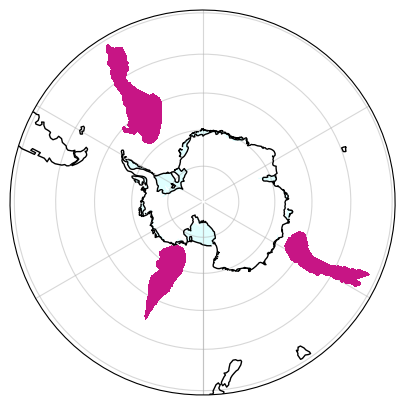

In [33]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
ax.contourf(catalog_slice.lon, catalog_slice.lat, catalog_slice, levels, cmap=colormap, transform=ccrs.PlateCarree(), zorder=31)
ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
#ax.add_feature(land_50m,linewidth=3)
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
ax.gridlines(alpha=0.5, zorder=33)



In [34]:
catalog_slice

<xarray.DataArray 'ar_binary_tag' (lat: 95, lon: 576)> Size: 55kB
dask.array<getitem, shape=(95, 576), dtype=int8, chunksize=(95, 576), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
    time     datetime64[ns] 8B 1980-02-08T18:00:00
Attributes:
    scheme:        Wille_vIVT
    description:   Binary indicator of atmospheric river using vIVT
    version:       2.4
    credits:       Developed by Jonathan D. Wille, Ambroise Dufour, Jai Chowd...
    cell_methods:  time: mean

In [39]:
synoptic_scale = 10**3
km_per_radian = 6.371*(10**3) # arclength (km) on earth subtended by 1 radian
eps_space = synoptic_scale/(2*km_per_radian) # converted to radians for Haversine metric

inds = np.argwhere(catalog_slice.to_numpy() == 1)
storm_lats = catalog_slice.lat[inds[:,0]]
storm_lons = catalog_slice.lon[inds[:,1]]
points = np.column_stack((np.radians(storm_lats), np.radians(storm_lons)))

In [42]:
clustering = DBSCAN(eps=eps_space, min_samples=5, metric='haversine').fit_predict(points)
fixed_time_df = pd.DataFrame({'lats': storm_lats, 'lons': storm_lons, 'cluster': clustering})

In [44]:
rep_pts = fixed_time_df.groupby('cluster', as_index=False)[['lats', 'lons']].agg(lambda x: list(np.random.choice(x, min(10, len(x)), replace=False)))

In [59]:
storm0

,lats,lons,cluster
0,-75.5,-157.500,0
1,-75.5,-156.875,0
2,-75.5,-156.250,0
3,-75.5,-155.625,0
4,-75.5,-155.000,0
...,...,...,...
1820,-55.5,-153.750,0
1821,-55.5,-153.125,0
1849,-55.0,-153.750,0
1850,-55.0,-153.125,0


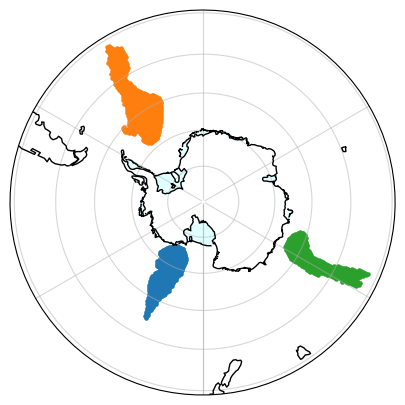

In [81]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
storm0 = fixed_time_df[fixed_time_df.cluster == 0]
ax.scatter(x=storm0.lons, y=storm0.lats, transform=ccrs.PlateCarree(), s=5)
storm1 = fixed_time_df[fixed_time_df.cluster == 1]
ax.scatter(x=storm1.lons, y=storm1.lats, transform=ccrs.PlateCarree(), s=5)
storm2 = fixed_time_df[fixed_time_df.cluster == 2]
ax.scatter(x=storm2.lons, y=storm2.lats, transform=ccrs.PlateCarree(), s=5)

ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
#ax.add_feature(land_50m,linewidth=3)
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
ax.gridlines(alpha=0.5, zorder=33)



In [82]:
plt_path = str(Path(os.getcwd()).parents[0]) + '/plots/'
fig.savefig(plt_path + 'not_subsampled.png')

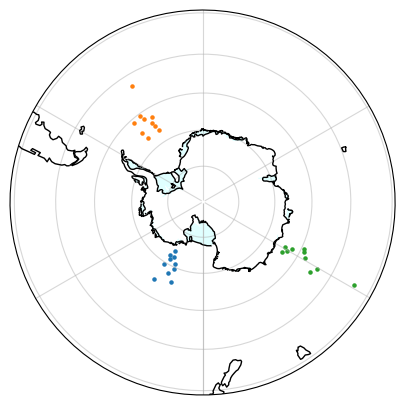

In [83]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
ax.scatter(x=rep_pts.lons.loc[0], y=rep_pts.lats.loc[0], transform=ccrs.PlateCarree(), s=5)
ax.scatter(x=rep_pts.lons.loc[1], y=rep_pts.lats.loc[1], transform=ccrs.PlateCarree(), s=5)
ax.scatter(x=rep_pts.lons.loc[2], y=rep_pts.lats.loc[2], transform=ccrs.PlateCarree(), s=5)

ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
#ax.add_feature(land_50m,linewidth=3)
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
ax.gridlines(alpha=0.5, zorder=33)

In [84]:
plt_path = str(Path(os.getcwd()).parents[0]) + '/plots/'
fig.savefig(plt_path + 'subsampled.png')